In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import arviz as az
import numpy as np


plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.load import load_multisensory_data
from cppp.utils import concat_log_likelihoods


/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check model diagnostics

In [16]:
# get the participant IDs from the data
participants = load_multisensory_data(base_path="../data")["participant"].unique()
participants = participants[:1]
len(participants)

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)


1

In [17]:
def load_model(participant, model_name, seed=7453, num_warmup=1000):
    if num_warmup > 2500:
        raise FileNotFoundError(f"num_warmup must be <= 2500, got {num_warmup}")
    try:
        model = az.from_netcdf(
            f"../results/multisensory-mcmc-{participant}_1_2_{seed}_{num_warmup}_2500_4_optimal_{model_name}_['prop', 'vis'].nc"
        )
    except FileNotFoundError:
        model = load_model(participant, model_name, seed=seed, num_warmup=num_warmup+500)
    return model


summaries = []
loos = []
for participant in participants:
    # define the model names to load
    model_names = [
        "BoundedActorPointMassDynamics",
        "BoundedActor",
        "OptimalActorPointMassDynamics",
        "OptimalActor",
    ]

    # dict for model comparisons
    models = {}

    # load the models for this participant
    for model_name in model_names:
        model = None
        seed = 7452
        while seed <= 7455 and model is None:
            # print(f"Trying to load model {model_name} for participant {participant} with seed {seed}.")
            try:
                model = load_model(participant, model_name, seed=seed)
            except FileNotFoundError:
                print(f"Model {model_name} for participant {participant} with seed {seed} not found, trying next seed.")
                seed += 1
                continue
            
            if az.summary(model)["r_hat"].max() > 1.05:
                print(f"Model {model_name} for participant {participant} with seed {seed} has r_hat > 1.05, trying next seed.")
                
                seed += 1
                # model = None
                continue

        if model is None:
            print(f"Could not find valid model fit {model_name} for participant {participant}, seed {seed-1}.")
            continue
            # model = load_model(participant, model_name, seed=seed+1)

        summary = az.summary(model)

        # stack up log likelihoods for all 6 conditions into a single array for each model so that we can perform model comparison using all conditions together
        model = concat_log_likelihoods(model)
        # put model into dict
        models[model_name] = model

        # add the model name and participant to the summary dataframe
        summary["model"] = model_name
        summary["participant"] = participant
        summary["seed"] = seed
        summaries.append(summary)

        # compute the Pareto-smoothed importance sampling leave-one-out cross-validation (PSIS-LOO) for the model
        loo = az.loo(model)
        loo["model"] = model_name
        loo["participant"] = participant
        loos.append({
            "participant": participant,
            "model": model_name,
            "elpd_loo": loo.elpd_loo,
            "se": loo.se,
        })

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

In [22]:
model = load_model(participants[0], "BoundedActorPointMassDynamics", seed=7452)
model.posterior["action_cost"].mean()

<xarray.DataArray 'action_cost' ()> Size: 4B
array(2.1823091e-07, dtype=float32)

In [4]:
df = pd.concat(summaries).reset_index().rename(columns={"index": "parameter"})
df


,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant,seed
0,action_cost,0.000,0.000,0.000,0.000,0.000,0.000,13311.0,8060.0,1.0,BoundedActorPointMassDynamics,135033060,7452
1,action_variability,0.081,0.001,0.080,0.083,0.000,0.000,12806.0,8313.0,1.0,BoundedActorPointMassDynamics,135033060,7452
2,sigma_prop,2.931,0.099,2.752,3.122,0.001,0.001,12497.0,8033.0,1.0,BoundedActorPointMassDynamics,135033060,7452
3,sigma_vis[0],4.102,0.219,3.702,4.514,0.002,0.002,12034.0,7873.0,1.0,BoundedActorPointMassDynamics,135033060,7452
4,sigma_vis[1],11.958,0.785,10.543,13.479,0.007,0.008,11937.0,7977.0,1.0,BoundedActorPointMassDynamics,135033060,7452
5,action_cost,0.000,0.000,0.000,0.000,0.000,0.000,12284.0,8216.0,1.0,BoundedActor,135033060,7452
6,action_variability,0.154,0.004,0.146,0.162,0.000,0.000,12167.0,8154.0,1.0,BoundedActor,135033060,7452
7,sigma_prop,3.359,0.117,3.143,3.582,0.001,0.001,12561.0,8395.0,1.0,BoundedActor,135033060,7452
8,sigma_vis[0],5.051,0.304,4.474,5.610,0.003,0.003,11594.0,7358.0,1.0,BoundedActor,135033060,7452
9,sigma_vis[1],14.056,0.985,12.237,15.936,0.009,0.011,11944.0,7720.0,1.0,BoundedActor,135033060,7452


In [5]:
loo_df = pd.DataFrame(loos)
loo_df

,participant,model,elpd_loo,se
0,135033060,BoundedActorPointMassDynamics,-7233.342880,270.878131
1,135033060,BoundedActor,-8296.752304,272.518977
2,135033060,OptimalActorPointMassDynamics,-7868.213745,349.327192
3,135033060,OptimalActor,-11002.897812,405.196345
4,173058413,BoundedActorPointMassDynamics,-15812.112427,181.200138
5,173058413,BoundedActor,-15594.652985,189.334215
6,173058413,OptimalActorPointMassDynamics,-15825.200256,173.445686
7,173058413,OptimalActor,-15703.075897,180.775303


In [6]:
# comparison_df = comparison_df.reset_index().rename(columns={"index": "model"})

short_model_name = {
    "BoundedActorPointMassDynamics": "Point-mass with cost",
    "BoundedActor":                  "Velocity with cost",
    "OptimalActorPointMassDynamics": "Point-mass without cost",
    "OptimalActor":                  "Velocity without cost",
}
loo_df["model_short"] = loo_df["model"].map(short_model_name)
df["model_short"] = df["model"].map(short_model_name)

df["cost"] = df["model_short"].apply(lambda x: "with cost" if "with cost" in x else "without cost")
df["dynamics"] = df["model_short"].apply(lambda x: "Point-mass" if "Point-mass" in x else "Velocity")

model_order = ["Point-mass with cost", "Velocity with cost", "Point-mass without cost", "Velocity without cost"]
palette     = dict(zip(model_order, sns.color_palette("colorblind", 4)))

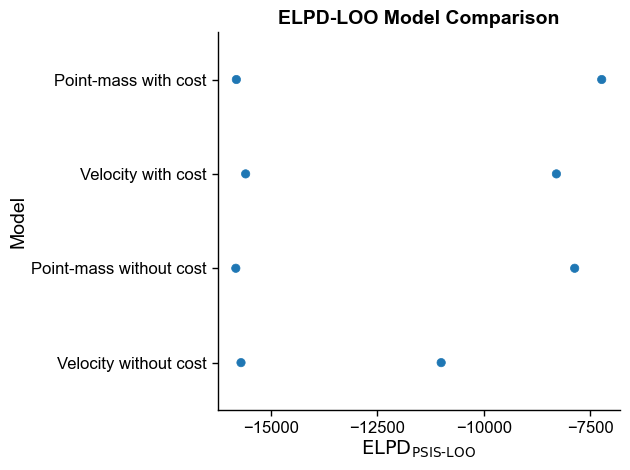

In [7]:
g = (so.Plot(loo_df, y="model_short", x="elpd_loo")
      .add(so.Dot())
    #   .add(so.Range())
      # .add(so.Dot(pointsize=2), so.Jitter())
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=4))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Model", title="ELPD-LOO Model Comparison")
      .show()
)

## Model comparison for all participants

/tmp/ipykernel_3964046/688741689.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


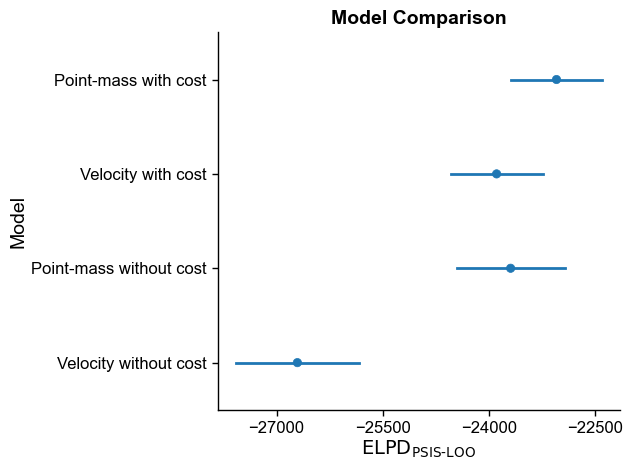

In [8]:
# sum up ELPDs across participants for each model, and compute the standard error of the sum
group_stats = (
    loo_df.groupby("model_short")
    .apply(lambda x: pd.Series({
        "elpd_loo_sum": x["elpd_loo"].sum(),
        "se_sum": np.sqrt((x["se"] ** 2).sum()),
    }))
    .reindex(model_order)
    .reset_index()
)

# compute the lower and upper bounds of ELPD 95 % CIs (+- 1.96 * se) of the ELPD-LOO sum for each model
group_stats["elpd_low"] = group_stats["elpd_loo_sum"] - 1.96 * group_stats["se_sum"]
group_stats["elpd_high"] = group_stats["elpd_loo_sum"] + 1.96 * group_stats["se_sum"]

g = (so.Plot(group_stats, y="model_short", x="elpd_loo_sum")
      .add(so.Dot())
      .add(so.Range(), xmin="elpd_low", xmax="elpd_high")
      # .add(so.Dot(pointsize=2), so.Jitter())
      .scale(y=so.Nominal(order=model_order),
             x=so.Continuous().tick(upto=4))
      .label(x=r"$\text{ELPD}_{\text{PSIS-LOO}}$", y="Model", title="Model Comparison")
      .show()
)

## Best-fitting model per participant

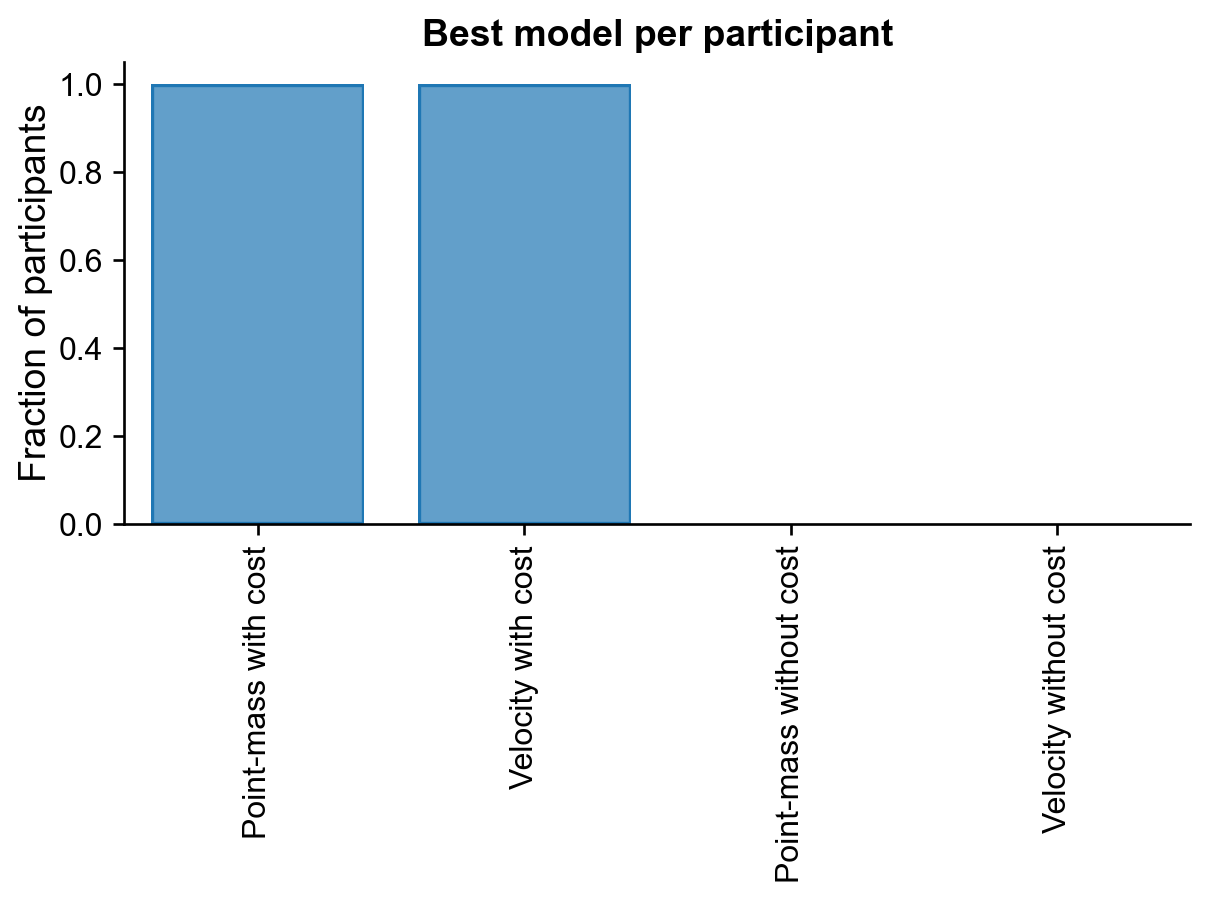

In [9]:
best_per_participant = (
    loo_df.loc[loo_df.groupby("participant")["elpd_loo"].idxmax(), ["model_short", "participant"]]
)

win_counts = (
    best_per_participant["model_short"].value_counts()
    .reindex(model_order, fill_value=0)
    .reset_index()
)
win_counts.columns = ["model_short", "wins"]
win_counts["n_participants"] = win_counts["wins"] 

g = (
    so.Plot(win_counts, x="model_short", y="n_participants")
    .add(so.Bar())
    .scale(x=so.Nominal(order=model_order))
    .label(x="", y="Fraction of participants", title="Best model per participant")
).plot()
for axis in g._figure.axes:
    axis.xaxis.set_tick_params(rotation=90)
g

## Model parameters

We extract the parameters of the best-fitting model per participant

In [10]:
param_names = {"sigma_prop": "Proprioceptive", "sigma_vis[0]": "Visual (cursor)", "sigma_vis[1]": "Visual (blob)",
               "action_variability": "Action variability", "action_cost": "Action cost"}

In [11]:
# get the parts of df that correspond to the best model for each participant
best_model_params = df.merge(best_per_participant, on=["participant", "model_short"])
best_model_params["parameter"] = best_model_params["parameter"].map(lambda x: param_names.get(x, x))
df["parameter"] = df["parameter"].map(lambda x: param_names.get(x, x))


In [12]:
df[
    df["parameter"].isin(["Action cost"])
]# .groupby("parameter")["mean"].agg(["mean", "std", "min", "max"])

,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant,seed,model_short,cost,dynamics
0,Action cost,0.0,0.0,0.0,0.000,0.0,0.0,13311.0,8060.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
5,Action cost,0.0,0.0,0.0,0.000,0.0,0.0,12284.0,8216.0,1.0,BoundedActor,135033060,7452,Velocity with cost,with cost,Velocity
18,Action cost,0.0,0.0,0.0,0.000,0.0,0.0,6432.0,5439.0,1.0,BoundedActorPointMassDynamics,173058413,7452,Point-mass with cost,with cost,Point-mass
23,Action cost,0.0,0.0,0.0,0.001,0.0,0.0,10393.0,6753.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity


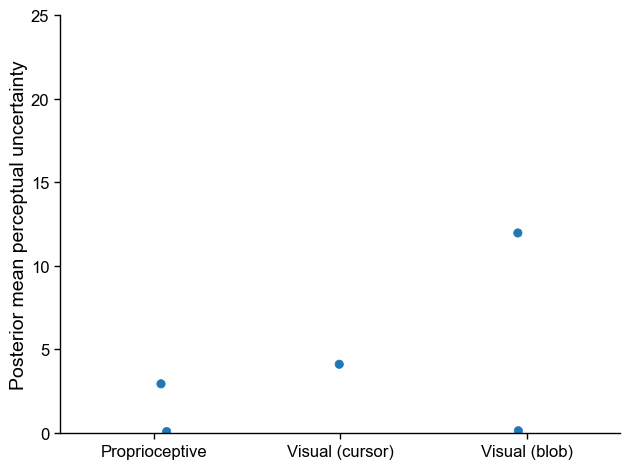

In [13]:


g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Proprioceptive", "Visual (cursor)", "Visual (blob)"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    .limit(y=(0, 25.0))
    .label(x="", y="Posterior mean perceptual uncertainty")
    .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.show()

In [14]:
best_model_params

,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant,seed,model_short,cost,dynamics
0,Action cost,0.000,0.000,0.000,0.000,0.000,0.000,13311.0,8060.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
1,Action variability,0.081,0.001,0.080,0.083,0.000,0.000,12806.0,8313.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
2,Proprioceptive,2.931,0.099,2.752,3.122,0.001,0.001,12497.0,8033.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
3,Visual (cursor),4.102,0.219,3.702,4.514,0.002,0.002,12034.0,7873.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
4,Visual (blob),11.958,0.785,10.543,13.479,0.007,0.008,11937.0,7977.0,1.0,BoundedActorPointMassDynamics,135033060,7452,Point-mass with cost,with cost,Point-mass
5,Action cost,0.000,0.000,0.000,0.001,0.000,0.000,10393.0,6753.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity
6,Action variability,1.441,0.015,1.413,1.470,0.000,0.000,10778.0,6139.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity
7,Proprioceptive,0.076,0.058,0.000,0.178,0.001,0.001,5804.0,3738.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity
8,Visual (cursor),26.486,4.899,18.356,35.923,0.052,0.062,9808.0,6563.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity
9,Visual (blob),0.123,0.093,0.000,0.286,0.001,0.001,6270.0,3908.0,1.0,BoundedActor,173058413,7452,Velocity with cost,with cost,Velocity


/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/seaborn/_core/plot.py:1492: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  view["ax"].autoscale_view()


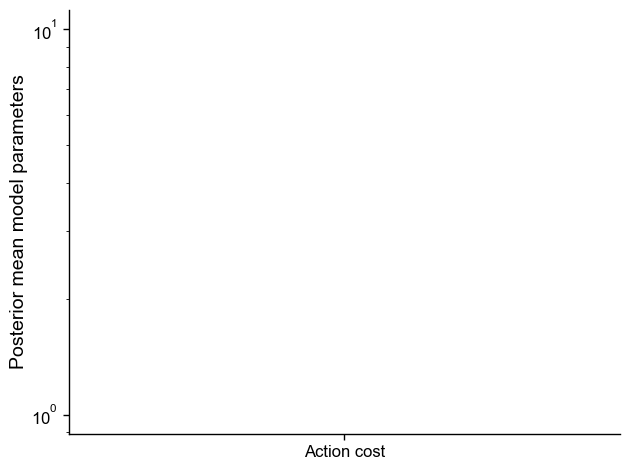

In [15]:
g = (
    so.Plot(
        best_model_params[
            (
                best_model_params["parameter"].isin(
                    ["Action cost"]
                )
            )
        ],
        x="parameter",
        y="mean",
        # color="model_short",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    # .add(so.Dot(), so.Agg())
    # .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 1.0))
    .label(x="", y="Posterior mean model parameters")
    .scale(color=so.Nominal(), y="log")
    # .facet(col="parameter")
    # .share(y=False)
)
g.show()

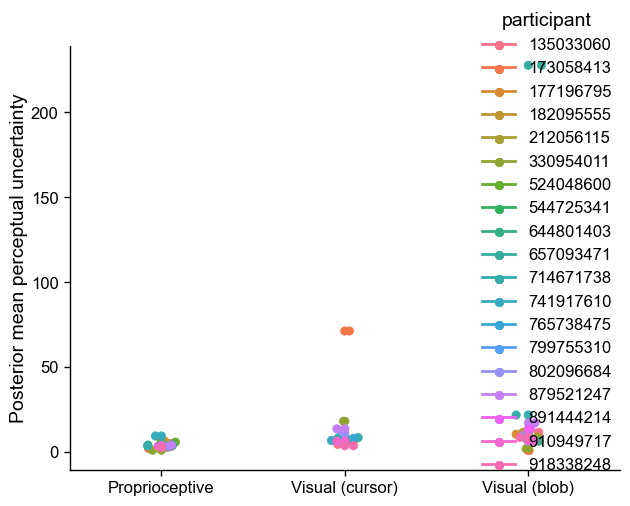

In [28]:

g = (
    so.Plot(
        df[(df["parameter"].isin(["Proprioceptive", "Visual (cursor)", "Visual (blob)"])) & (df["model_short"] == "Point-mass with cost")],
        x="parameter",
        y="mean",
        color="participant",
    )
    .add(so.Dot(), so.Jitter())
    # .add(so.Line(), group="participant")
    .add(so.Dot(), so.Agg())
    .add(so.Range(), so.Est(errorbar="se"))
    # .limit(y=(0, 25.0))
    .label(x="", y="Posterior mean perceptual uncertainty")
    .scale(color=so.Nominal())
    # .facet(col="parameter")
    # .share(y=False)
)
g.show()

In [28]:
df[df["mean"] > 200.0]

,parameter,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,model,participant,seed,model_short,cost,dynamics
19,Visual (blob),340.632,16.897,310.274,373.686,0.213,0.185,6314.0,5402.0,1.0,OptimalActor,135033060,7452,Velocity without cost,without cost,Velocity
54,Visual (blob),272.495,16.247,240.785,301.738,0.192,0.172,7162.0,5716.0,1.0,OptimalActorPointMassDynamics,177196795,7452,Point-mass without cost,without cost,Point-mass
57,Proprioceptive,364.544,17.417,332.599,398.068,0.189,0.178,8601.0,7448.0,1.0,OptimalActor,177196795,7452,Velocity without cost,without cost,Velocity
58,Visual (cursor),353.404,18.863,318.930,389.433,0.203,0.192,8614.0,6635.0,1.0,OptimalActor,177196795,7452,Velocity without cost,without cost,Velocity
59,Visual (blob),510.479,22.155,469.073,552.816,0.237,0.241,8732.0,6415.0,1.0,OptimalActor,177196795,7452,Velocity without cost,without cost,Velocity
139,Visual (blob),414.179,20.099,377.030,452.701,0.235,0.209,7345.0,6538.0,1.0,OptimalActor,524048600,7452,Velocity without cost,without cost,Velocity
158,Visual (cursor),503.142,20.978,462.931,541.169,0.213,0.209,9696.0,7638.0,1.0,OptimalActor,544725341,7452,Velocity without cost,without cost,Velocity
159,Visual (blob),476.098,20.284,438.433,514.727,0.224,0.215,8225.0,6313.0,1.0,OptimalActor,544725341,7452,Velocity without cost,without cost,Velocity
184,Visual (blob),227.799,10.878,207.695,247.946,0.099,0.109,12158.0,7454.0,1.0,BoundedActorPointMassDynamics,657093471,7453,Point-mass with cost,with cost,Point-mass
194,Visual (blob),221.489,11.034,200.071,241.731,0.112,0.112,9709.0,7147.0,1.0,OptimalActorPointMassDynamics,657093471,7453,Point-mass without cost,without cost,Point-mass
